In [6]:
import pandas as pd
import matplotlib.pyplot as plt
# 设置最多显示200行和50列（无省略号）
pd.set_option('display.max_rows', 200)      # 最大行数
pd.set_option('display.max_columns', 50)    # 最大列数
pd.set_option('display.width', None)        # 自动适应终端宽度
pd.set_option('display.max_colwidth', None) # 列内容不被截断（可选）

import numpy as np

def plot_cols(feat_col, feature_all_df):
    # # 假设你已经有以下变量
    # feat_col = 'Around3s_AvgPrc_minusclose'
    ret_cols = ['LA300', 'LA1800']


    df = feature_all_df.reset_index()

    # ---------- 全部时间点 (FR_all_*) ----------
    fr_all_results = {}
    for ret_col in ret_cols:
        sub_df = df[[feat_col, ret_col, 'date']].dropna()

        # 按date groupby，计算 FR = cov(x, y) / std(x)
        grouped = sub_df.groupby('date')
        mean_x = grouped[feat_col].transform('mean')
        mean_y = grouped[ret_col].transform('mean')
        std_x = grouped[feat_col].transform('std')

        cov_xy = ((sub_df[feat_col] - mean_x) * (sub_df[ret_col] - mean_y)).groupby(sub_df['date']).mean()
        std_x_daily = std_x.groupby(sub_df['date']).first()  # std(x)是一样的，随便取一个就行

        fr = cov_xy / std_x_daily.replace(0, np.nan)
        fr_all_results[f'FR_all_{ret_col}'] = fr

    # ---------- 特定时间点 (FR_{time}_{ret_col}) ----------
    fr_time_results = {}


    # 合并所有结果
    fr_df = pd.DataFrame(fr_all_results)
    cumulative_fr_df = fr_df.cumsum()

    # 分别提取 ret0e 和 ret1h 的 FR 列
    fr_0e_cols = [col for col in cumulative_fr_df.columns if 'LA300' in col]
    fr_1h_cols = [col for col in cumulative_fr_df.columns if 'LA1800' in col]
    

    # 画 ret0e_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_0e_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'{feat_col} Cumulative FR (LA300_shift)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()

    # 画 ret1h_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_1h_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'{feat_col} Cumulative FR (LA1800_shift) -|')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()
#     fr_df.to_parquet(f'/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/fr_save/{feat_col}.parquet', engine="pyarrow", compression="snappy")
    


In [7]:
import pandas as pd, glob, datetime as dt
import os
# from tqdm import tqdm
dictionary = '../../crypto_futures_data/SOLUSDT/'
start, end = dt.date(2025,6,1), dt.date(2025,8,24)
df = pd.concat([pd.read_csv(f).assign(date=f[-14:-4])
                for f in (sorted(glob.glob(os.path.join(dictionary, 'SOLUSDT-aggTrades-*/SOLUSDT-aggTrades-*.csv'))))
                if start <= dt.datetime.strptime(f[-14:-4], '%Y-%m-%d').date() <= end])

In [8]:
import pandas as pd, glob, datetime as dt
import os
# from tqdm import tqdm
dictionary = '../../crypto_futures_data/SOLUSDT/'
start, end = dt.date(2025,6,1), dt.date(2025,8,24)
df_kline = pd.concat([pd.read_csv(f).assign(date=f[-14:-4])
                for f in (sorted(glob.glob(os.path.join(dictionary, 'SOLUSDT-1m-*.csv'))))
                if start <= dt.datetime.strptime(f[-14:-4], '%Y-%m-%d').date() <= end])

In [18]:
import pandas as pd, glob, datetime as dt
import os
# from tqdm import tqdm
dictionary = '../../crypto_futures_data/SOLUSDT/'
start, end = dt.date(2025,6,1), dt.date(2025,8,24)
df_book = pd.concat([pd.read_csv(f).assign(date=f[-14:-4])
                for f in (sorted(glob.glob(os.path.join(dictionary, 'SOLUSDT-bookdepth-*.csv'))))
                if start <= dt.datetime.strptime(f[-14:-4], '%Y-%m-%d').date() <= end])

In [ ]:
df['datetime'] = pd.to_datetime(df['transact_time'], unit='ms')
df['ceil_min']  = df['datetime'].dt.ceil('T')

df_kline['datetime'] = pd.to_datetime( df_kline['close_time'], unit='ms')
df_kline['ceil_min'] = df_kline['datetime'].dt.ceil('T')

df_1min = (
    df
    .groupby(['ceil_min'])
    .agg(
        agg_trade_id_count=('agg_trade_id', 'count'),
        price_avg          =('price',          'mean'),
        quantity_sum       =('quantity',       'sum'),
        have_buyer_maker   =('is_buyer_maker', 'sum')
    )
)

df_kline.set_index('ceil_min', inplace=True)
df_merge = df_1min.merge(df_kline,left_index=True, right_index=True, how='right')

C:\Users\PHBS\AppData\Local\Temp\ipykernel_9012\684155206.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df['ceil_min']  = df['datetime'].dt.ceil('T')
C:\Users\PHBS\AppData\Local\Temp\ipykernel_9012\684155206.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_kline['ceil_min'] = df_kline['datetime'].dt.ceil('T')


In [32]:
df_book['ceil_min']

0      2025-06-01 00:01:00
1      2025-06-01 00:02:00
2      2025-06-01 00:02:00
3      2025-06-01 00:02:00
4      2025-06-01 00:03:00
               ...        
2790   2025-08-16 23:58:00
2791   2025-08-16 23:59:00
2792   2025-08-16 23:59:00
2793   2025-08-17 00:00:00
2794   2025-08-17 00:00:00
Name: ceil_min, Length: 216855, dtype: datetime64[ns]

In [31]:
df_book['ceil_min'] = pd.to_datetime(df_book['timestamp']).dt.ceil('T')


C:\Users\PHBS\AppData\Local\Temp\ipykernel_9012\373189447.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_book['ceil_min'] = pd.to_datetime(df_book['timestamp']).dt.ceil('T')


In [ ]:
df['LA300'] = df['close'].shift(-6) / df['close'].shift(-1) - 1.
df['LA600'] = df['close'].shift(-11) / df['close'].shift(-1) - 1.
df['LA1800'] = df['close'].shift(-31) / df['close'].shift(-1) - 1.
df['LA3600'] = df['close'].shift(-61) / df['close'].shift(-1) - 1.
df['datetime'] = pd.to_datetime(df['close_time'], unit='ms')
df['date'] = df['datetime'].dt.date
df.set_index('datetime', inplace=True)
df['instrument'] = 'SOLUSDT'

C:\Users\PHBS\AppData\Local\Temp\ipykernel_24612\2441791135.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result_df = filtered_df.groupby(['date', 'instrument'], group_keys=False).apply(calculate_group)


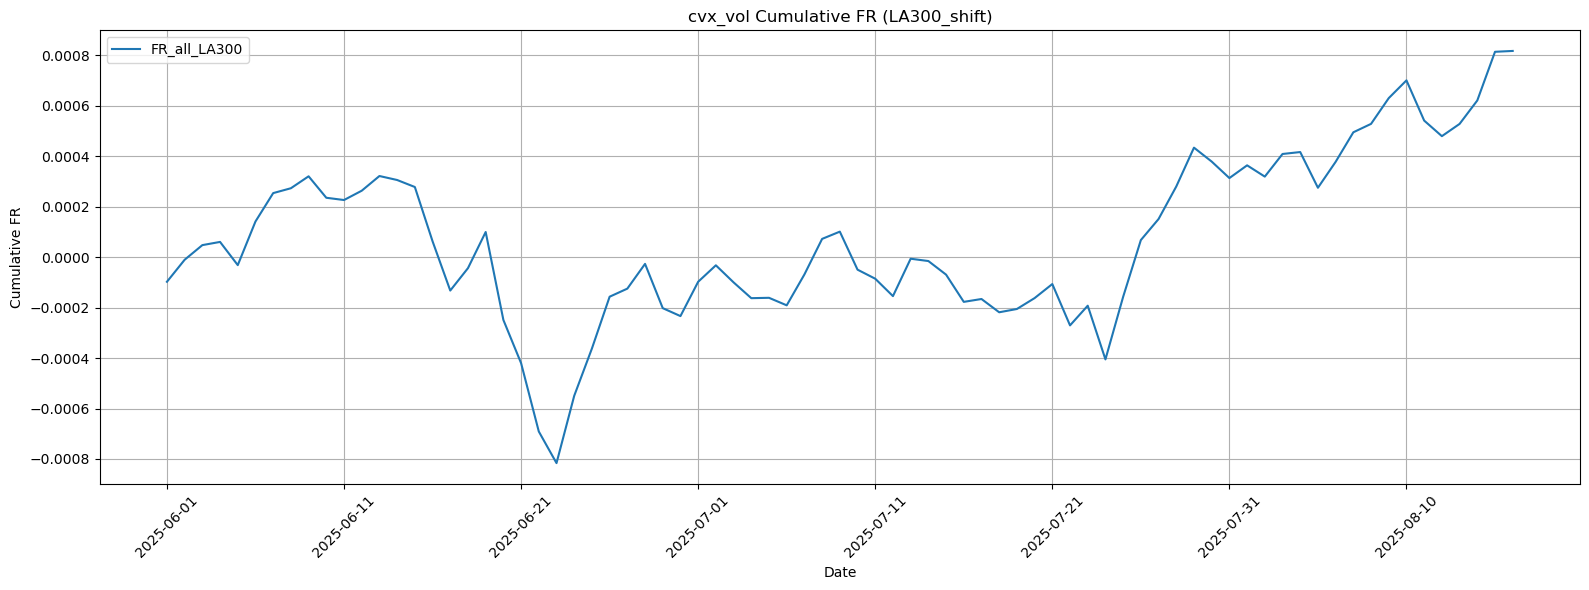

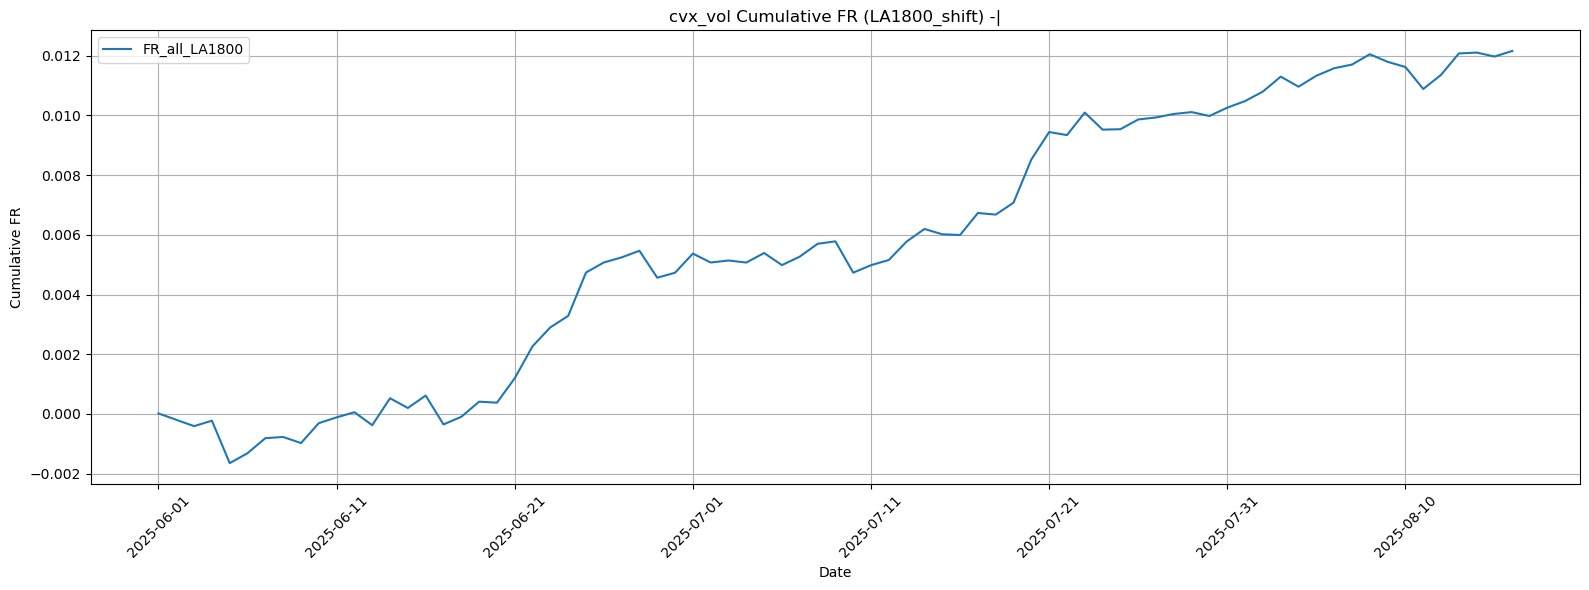

In [ ]:

def cvx_lws(vol):
    """
    实现cvx_lws指标计算
    vol: 输入的成交量序列
    """
    cumsum_vol = vol.cumsum()
    se_mean = cumsum_vol.mean()
    cumbffill = cumsum_vol.ffill().bfill()
    av_mean = (cumbffill.iloc[0] + cumbffill.iloc[-1]) / 2.0
    return (av_mean - se_mean) / se_mean

def get_intra900010(df, begDate, endDate):
    """
    获取指定日期范围内的因子数据
    df: 1分钟K线数据DataFrame，需包含'date'、'time'、'instrument'、'close'等列
    begDate, endDate: 日期范围
    """
    # 筛选日期范围内的数据
    mask = (df['date'] >= begDate) & (df['date'] <= endDate)
    filtered_df = df[mask].copy()
    # 按日期和股票分组计算cvx_lws因子
    # 首先计算20期移动窗口的cvx_lws值
    def calculate_group(group):
        group['cvx_vol'] = group['close'].rolling(window=20).apply(
            lambda x: -cvx_lws(x), raw=False
        )
        return group
    result_df = filtered_df.groupby(['date', 'instrument'], group_keys=False).apply(calculate_group)
    return result_df


import datetime
result_df = get_intra900010(df,datetime.date(2024, 1, 4), datetime.date(2025, 8, 30))
plot_cols('cvx_vol', result_df)

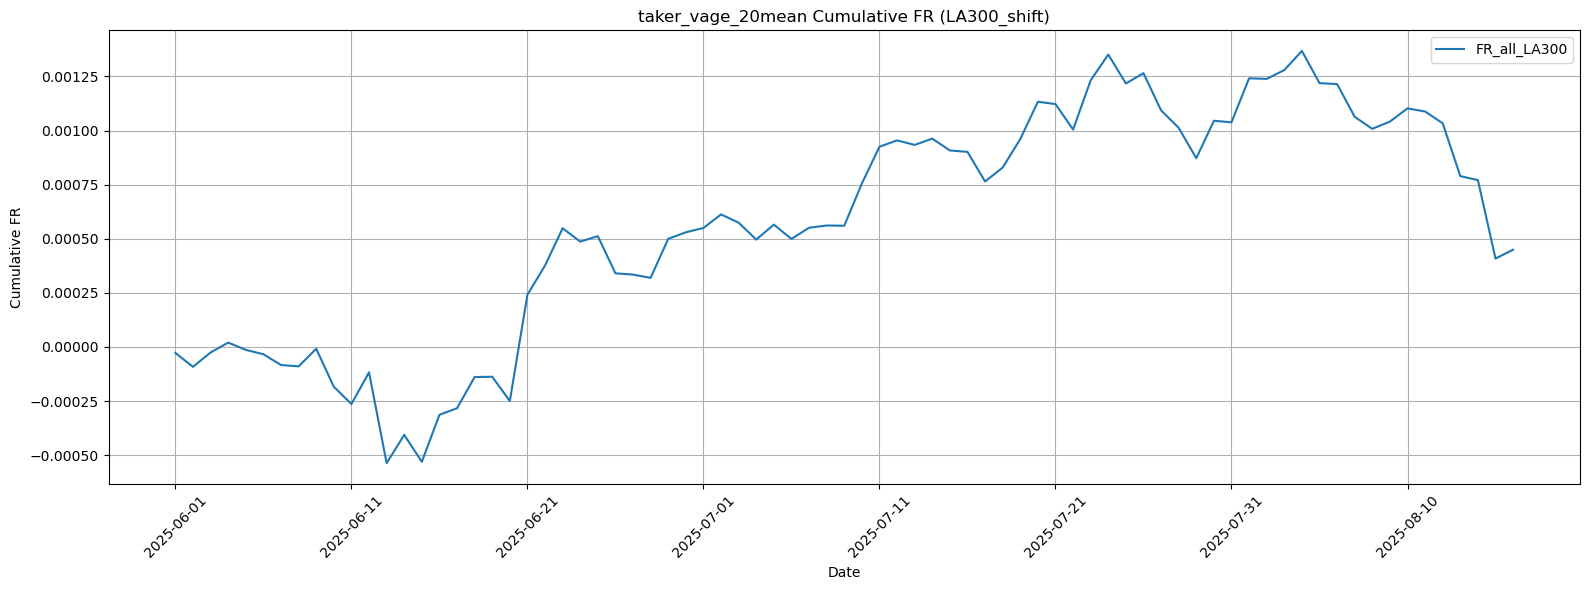

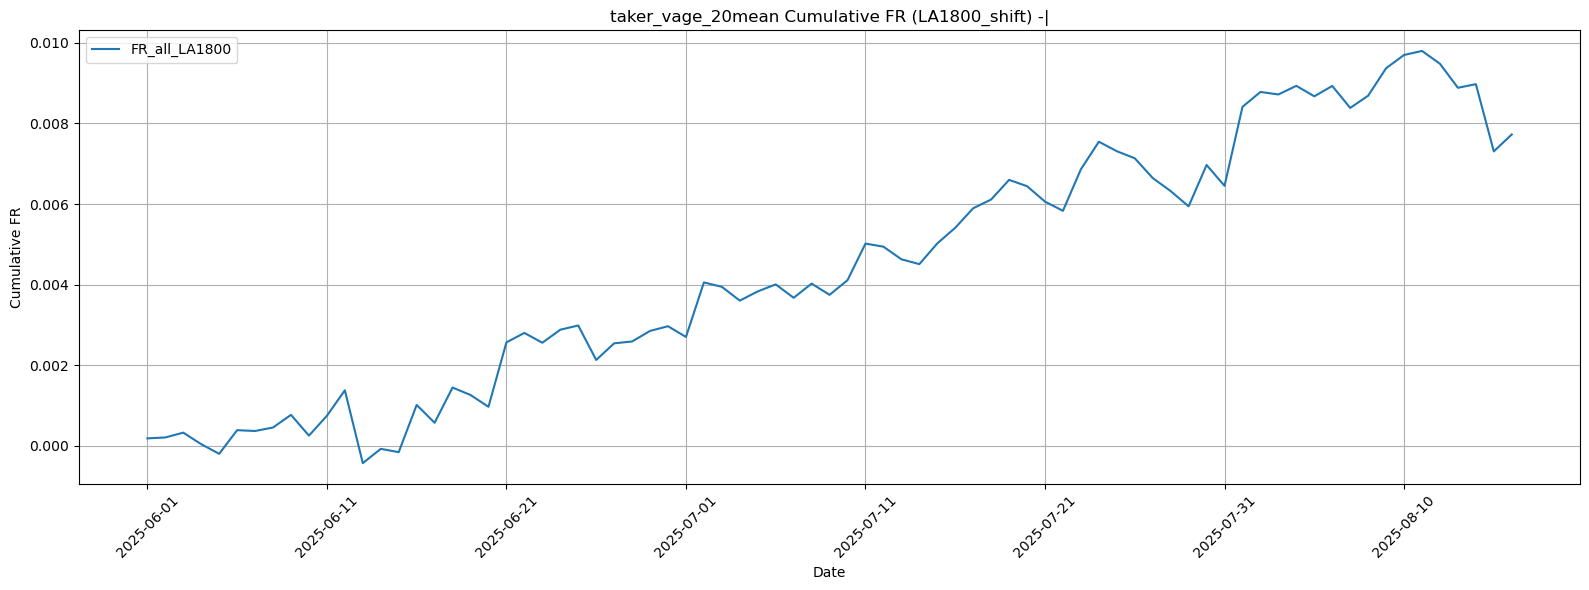

In [ ]:
# df['volume_per_count'] = df['volume'] / df['count']
# df['volume_per_count_std'] =  df['volume_per_count'].rolling(window=10).std()
df['taker_vage'] = df['taker_buy_quote_volume'] / df['quote_volume'] - df['taker_buy_volume'] / df['volume'] 
df['taker_vage_20mean'] = df['taker_vage'].rolling(window=20).mean()
plot_cols('taker_vage_20mean', df)